# **CODSOFT INTERNSHIP TASK 2**

# MOVIE RATING PREDICTION WITH PYTHON

# *Importing the needed Libraries*

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [10]:
movie_df = pd.read_csv("IMDb Movies IndiaC.csv")
movie_df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),2019.0,109 min,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,2019.0,110 min,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [11]:
 movie_df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),2019.0,109 min,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,2019.0,110 min,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,1988.0,NaN,Action,4.6,11.0,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,1999.0,129 min,"Action, Drama",4.5,655.0,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,2005.0,NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,1988.0,NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


* **The next set of code fill NAN values then convert to integer**

In [21]:
# Fill NAN values and convert to integer
movie_df['Year'] = movie_df['Year'].fillna(0).astype("int64")

#Fill NAN with the column mean (rounded)
movie_df['Year'] = movie_df['Year'].fillna(movie_df['Year'].mean()).round().astype("int64")

# Drop NAN values before conversion
movie_df.dropna(subset=['Year'], inplace=True)
movie_df['Year'] = movie_df['Year'].astype("int64")

In [26]:
# Fill NAN values and convert to integer
movie_df['Duration'] = movie_df['Duration'].fillna(0).astype("int64")

#Fill NAN with the column mean (rounded)
movie_df['Duration'] = movie_df['Duration'].fillna(movie_df['Duration'].mean()).round().astype("int64")

# Drop NAN values before conversion
movie_df.dropna(subset=['Duration'], inplace=True)
movie_df['Duration'] = movie_df['Duration'].astype("int64")

In [27]:
 # Fill NAN values and convert to integer
movie_df['Votes'] = movie_df['Votes'].fillna(0).astype("int64")

#Fill NAN with the column mean (rounded)
movie_df['Votes'] = movie_df['Votes'].fillna(movie_df['Votes'].mean()).round().astype("int64")

# Drop NAN values before conversion
movie_df.dropna(subset=['Votes'], inplace=True)
movie_df['Votes'] = movie_df['Votes'].astype("int64")

In [44]:
movie_df.dropna(inplace=True)
movie_df.drop_duplicates(inplace=True)

In [45]:
movie_df.dtypes

Name                        object
Year                         int64
Duration                     int64
Genre                       object
Rating                     float64
Votes                        int64
Director                    object
Actor 1                     object
Actor 2                     object
Actor 3                     object
Genre_Average_Rating       float64
Director_Average_Rating    float64
Actor1_Average_Rating      float64
Actor2_Average_Rating      float64
Actor3_Average_Rating      float64
dtype: object

In [50]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7558 entries, 1 to 15508
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     7558 non-null   object 
 1   Year                     7558 non-null   int64  
 2   Duration                 7558 non-null   int64  
 3   Genre                    7558 non-null   object 
 4   Rating                   7558 non-null   float64
 5   Votes                    7558 non-null   int64  
 6   Director                 7558 non-null   object 
 7   Actor 1                  7558 non-null   object 
 8   Actor 2                  7558 non-null   object 
 9   Actor 3                  7558 non-null   object 
 10  Genre_Average_Rating     7558 non-null   float64
 11  Director_Average_Rating  7558 non-null   float64
 12  Actor1_Average_Rating    7558 non-null   float64
 13  Actor2_Average_Rating    7558 non-null   float64
 14  Actor3_Average_Rating    755

In [29]:
# Exploratary Data Analysis

In [46]:
movie_df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Average_Rating,Director_Average_Rating,Actor1_Average_Rating,Actor2_Average_Rating,Actor3_Average_Rating
1,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,6.352082,7.000000,6.850000,7.000000,7.000000
3,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,5.722500,4.400000,5.420000,4.400000,4.450000
5,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,6.224490,5.358824,4.788889,5.786667,5.846154
6,...Yahaan,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,6.820000,7.500000,5.356000,6.050000,6.500000
8,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.463636,5.600000,5.600000,5.883333,5.600000


In [47]:
movie_df.describe(include='all')

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Average_Rating,Director_Average_Rating,Actor1_Average_Rating,Actor2_Average_Rating,Actor3_Average_Rating
count,7558,7558.000000,7558.000000,7558,7558.000000,7558.000000,7558,7558,7558,7558,7558.000000,7558.000000,7558.000000,7558.000000,7558.000000
unique,7038,NaN,NaN,416,NaN,NaN,2956,2415,2783,3031,NaN,NaN,NaN,NaN,NaN
top,Zindagi,NaN,NaN,Drama,NaN,NaN,Mahesh Bhatt,Jeetendra,Rekha,Pran,NaN,NaN,NaN,NaN,NaN
freq,4,NaN,NaN,1137,NaN,NaN,45,140,79,74,NaN,NaN,NaN,NaN,NaN
mean,NaN,1993.421011,99.911617,NaN,5.811127,2029.123842,NaN,NaN,NaN,NaN,5.818650,5.808742,5.813340,5.812077,5.810559
std,NaN,20.004711,61.888836,NaN,1.368255,11868.695754,NaN,NaN,NaN,NaN,0.561523,1.077587,1.009092,1.020180,1.032196
min,NaN,1917.000000,0.000000,NaN,1.100000,5.000000,NaN,NaN,NaN,NaN,2.400000,1.700000,1.400000,1.600000,1.700000
25%,NaN,1980.000000,0.000000,NaN,4.900000,18.000000,NaN,NaN,NaN,NaN,5.468266,5.150000,5.270000,5.200000,5.204167
50%,NaN,1996.000000,125.000000,NaN,6.000000,61.000000,NaN,NaN,NaN,NaN,5.761017,5.857143,5.900000,5.850000,5.900000
75%,NaN,2011.000000,144.000000,NaN,6.800000,456.000000,NaN,NaN,NaN,NaN,6.278571,6.570833,6.436800,6.437838,6.432500


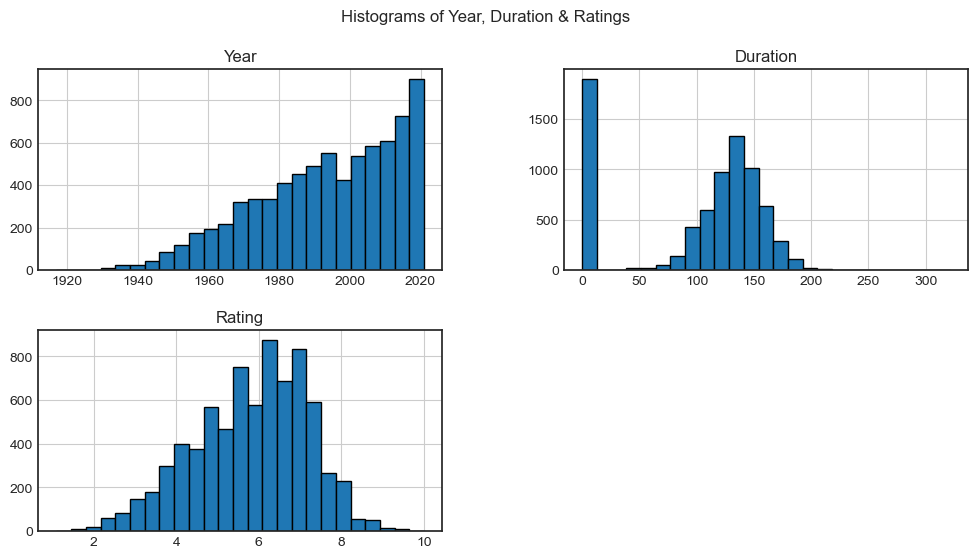

In [48]:
plt.style.use('seaborn-v0_8-white')
movie_df[['Year', 'Duration','Rating']].hist(bins=25, edgecolor='black',figsize=(12, 6))
plt.suptitle('Histograms of Year, Duration & Ratings ')
plt.show()

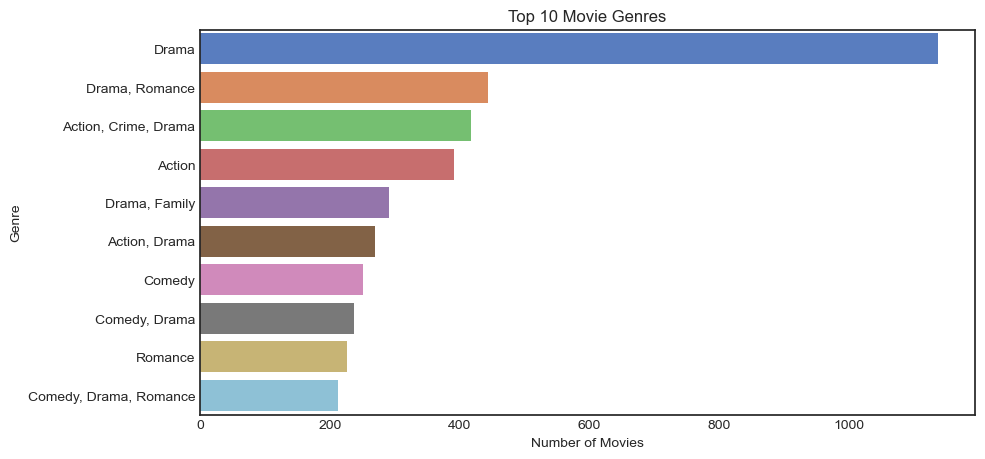

In [49]:
top_10_genres = movie_df['Genre'].value_counts(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index,  palette='muted')
plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

In [51]:
# Top 10 Actors With Most Movie Involvements
# Combine the three actor columns into one Series
combined_actors = pd.concat([movie_df['Actor 1'], movie_df['Actor 2'], movie_df['Actor 3']])

# Display the top 10 actors
top_10_actors = combined_actors.value_counts().head(10)
top_10_actors

Mithun Chakraborty    231
Dharmendra            217
Jeetendra             179
Ashok Kumar           173
Amitabh Bachchan      162
Rekha                 133
Rajesh Khanna         132
Shashi Kapoor         126
Sanjay Dutt           123
Shatrughan Sinha      120
Name: count, dtype: int64

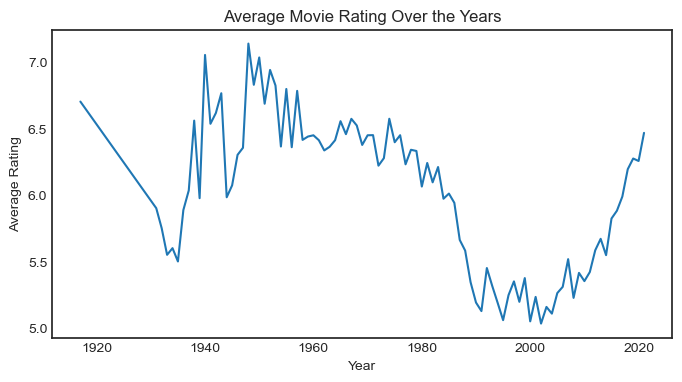

In [52]:
# Average Rating over these years

# Calculate the average rating for each year
average_rating_per_year = movie_df.groupby('Year')['Rating'].mean().reset_index()
average_rating_per_year.columns = ['Year', 'Average Rating']

#Plot
plt.figure(figsize=(8, 4))
plt.plot(average_rating_per_year['Year'], average_rating_per_year['Average Rating'], linestyle='-')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Movie Rating Over the Years')
plt.grid(False)
plt.show()

In [54]:
# High rated movie details
high_rating_movies = movie_df[movie_df['Rating'] > 8.5]
high_rating_movies

# Group by Rating and get the count of movies which have higher than rating value 8.5 
rating_counts = high_rating_movies.groupby('Rating')['Name'].count().reset_index()
rating_counts.columns = ['Rating', 'Number of Movies']
rating_counts = rating_counts.sort_values(by='Rating', ascending=False)
rating_counts

,Rating,Number of Movies
11,10.0,1
10,9.7,1
9,9.6,1
8,9.4,3
7,9.3,8
6,9.2,2
5,9.1,6
4,9.0,7
3,8.9,8
2,8.8,8


<Axes: >

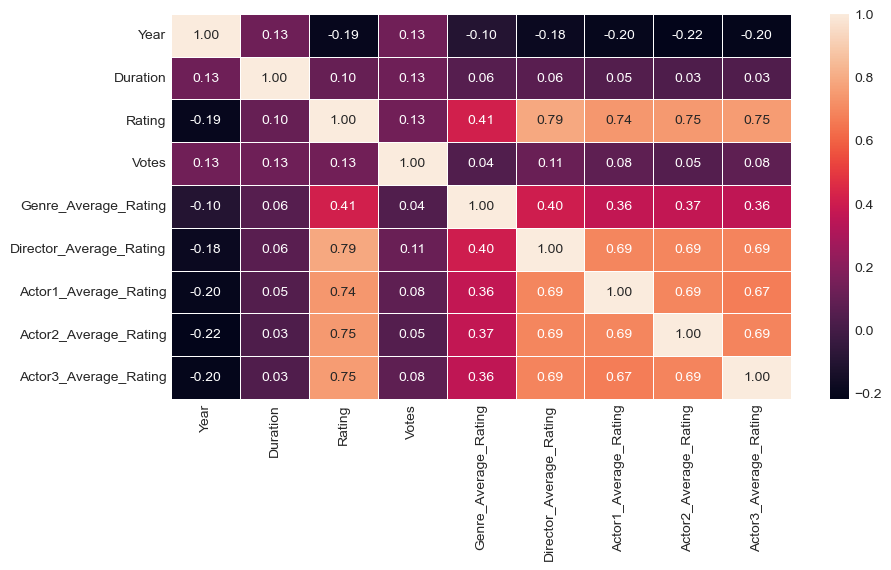

In [55]:
#Relationship between numeric variables
new_df=  movie_df.drop(columns=['Name','Actor 1','Actor 2','Actor 3','Director','Genre'])
corr=new_df.corr()
plt.figure(figsize=(10,5))

sns.heatmap(corr, annot=True, fmt=".2f", linewidth=0.5)



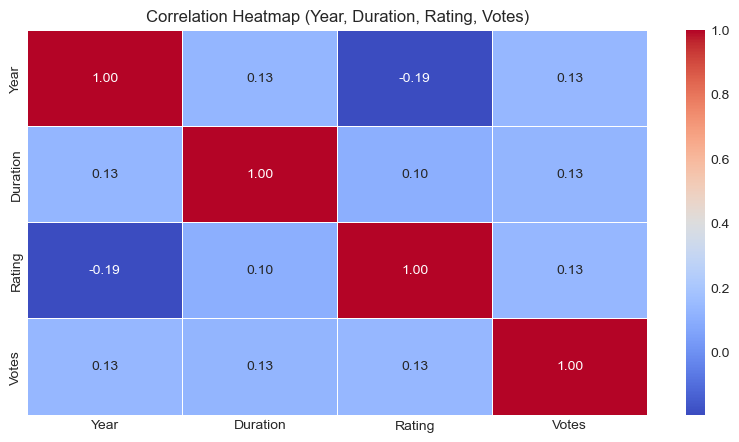

In [58]:
# Selecting only the desired columns
selected_features = ['Year', 'Duration', 'Rating', 'Votes']
corr_selected = new_df[selected_features].corr()

# Plotting the heatmap for the selected features
plt.figure(figsize=(10, 5))
sns.heatmap(corr_selected, annot=True, fmt=".2f", linewidth=0.5, cmap="coolwarm")

plt.title("Correlation Heatmap (Year, Duration, Rating, Votes)")
plt.show()


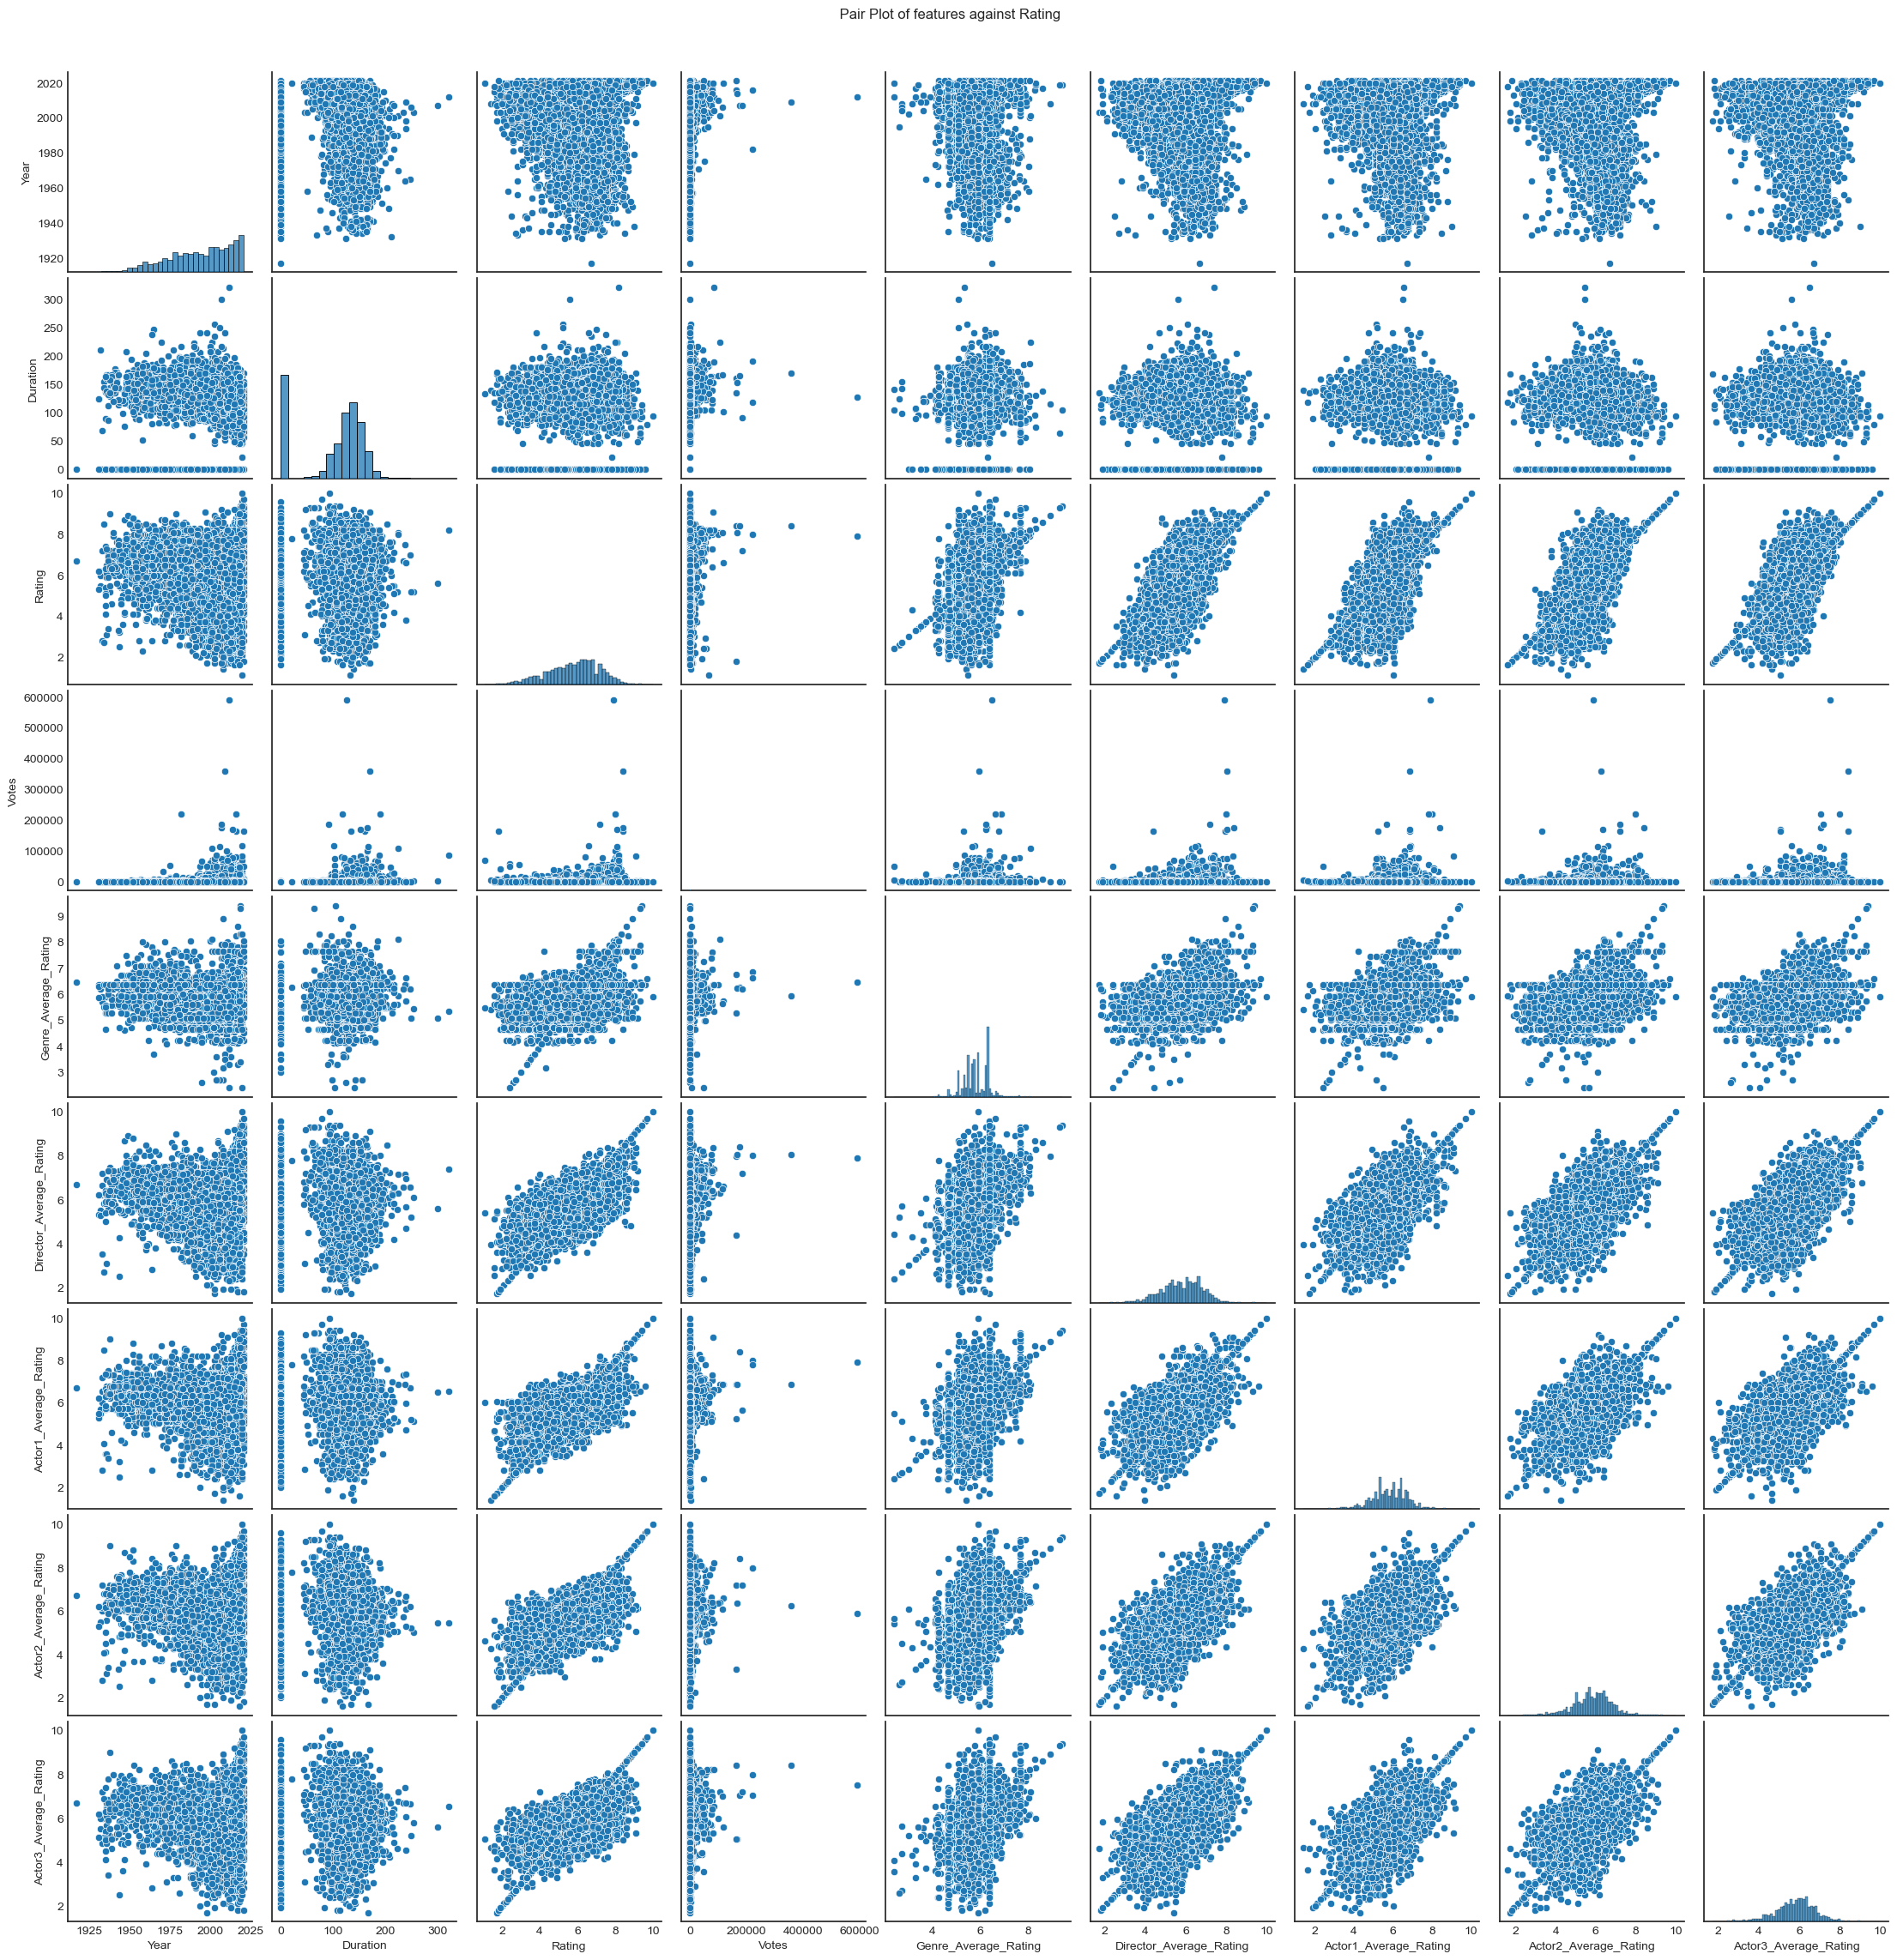

In [56]:
sns.pairplot(new_df,diag_kind='auto')
plt.suptitle(' Pair Plot of features against Rating', y=1.02)
plt.show()

In [59]:
df= movie_df.drop('Name',axis=1)

In [60]:
# Create new features 

Genre_Average_Rating = df.groupby('Genre')['Rating'].transform('mean')
df['Genre_Average_Rating'] =Genre_Average_Rating

Director_Average_Rating = df.groupby('Director')['Rating'].transform('mean')
df['Director_Average_Rating'] =Director_Average_Rating

Actor1_Average_Rating = df.groupby('Actor 1')['Rating'].transform('mean')
df['Actor1_Average_Rating'] =Actor1_Average_Rating

Actor2_Average_Rating = df.groupby('Actor 2')['Rating'].transform('mean')
df['Actor2_Average_Rating'] =Actor2_Average_Rating

Actor3_Average_Rating = df.groupby('Actor 3')['Rating'].transform('mean')
df['Actor3_Average_Rating'] =Actor3_Average_Rating

df

,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Average_Rating,Director_Average_Rating,Actor1_Average_Rating,Actor2_Average_Rating,Actor3_Average_Rating
1,2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,6.345910,7.000000,6.850000,7.000000,7.000000
3,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,5.700000,4.400000,5.420000,4.400000,4.450000
5,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,6.224490,5.358824,4.788889,5.786667,5.766667
6,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,6.820000,7.500000,5.300000,6.050000,6.500000
8,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.463636,5.600000,5.600000,5.883333,5.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15501,1992,0,"Action, Crime, Drama",5.3,135,Bharat Rangachary,Dharmendra,Moushumi Chatterjee,Govinda,5.616067,5.571429,5.742537,6.075000,4.895652
15503,1989,125,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth,5.616067,5.885714,6.328571,5.800000,5.850000
15504,1988,0,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand,5.045524,4.075000,6.025532,3.700000,4.600000
15505,1999,129,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani,5.460741,5.225000,5.481707,4.645455,5.617143


# Splitting Data

In [61]:
# Define feature and target variables
x= df[['Year','Votes','Duration','Genre_Average_Rating','Director_Average_Rating','Actor1_Average_Rating','Actor2_Average_Rating','Actor3_Average_Rating']]
y=df['Rating']

In [62]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state= 1 )

In [63]:
train_data= x_train.join(y_train)
train_data

,Year,Votes,Duration,Genre_Average_Rating,Director_Average_Rating,Actor1_Average_Rating,Actor2_Average_Rating,Actor3_Average_Rating,Rating
7885,2007,15,140,5.678088,6.644118,4.050000,5.300000,5.480000,3.8
14989,1982,5,0,5.511765,3.350000,4.000000,5.482609,6.688889,3.6
5223,1971,1028,121,6.460000,7.102381,5.742537,6.670000,7.600000,7.2
12977,2017,20,110,4.591129,4.050000,6.100000,4.966667,4.000000,4.0
3336,1981,58,0,4.591129,5.436000,5.714286,5.966667,5.818182,5.7
...,...,...,...,...,...,...,...,...,...
1714,1967,69,167,5.739906,6.169231,6.436800,6.715000,6.920000,6.5
10535,2000,67,143,6.088095,6.000000,4.825000,5.575000,5.500000,5.5
7948,2007,346,120,5.739906,3.600000,4.212500,5.612500,3.600000,3.6
401,2019,15,94,6.345910,6.600000,6.600000,6.600000,6.600000,6.6


In [64]:
from sklearn.tree import DecisionTreeRegressor

fitted_model_dt = DecisionTreeRegressor()
fitted_model_dt.fit(x_train, y_train)
y_pred_dt = fitted_model_dt.predict(x_test)

In [65]:
from sklearn.svm import SVR

fitted_model_svr = SVR()
fitted_model_svr.fit(x_train, y_train)
y_pred_svr = fitted_model_svr.predict(x_test)

In [66]:
from sklearn.ensemble import GradientBoostingRegressor

fitted_model_gb = GradientBoostingRegressor()
fitted_model_gb.fit(x_train, y_train)
y_pred_gb = fitted_model_gb.predict(x_test)

In [67]:
# Evaluating the model's performance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MSE_dt =  mean_squared_error(y_test, y_pred_dt) 
MAE_dt = mean_absolute_error(y_test, y_pred_dt)
R2_Score_dt = r2_score(y_test, y_pred_dt)

print('   Performance Evaluation for DecisionTreeRegressor Model: ')
print('Mean squared error value is: ', MSE_dt)
print('Mean absolute error value is: ', MAE_dt)
print('R2 score value is: ', R2_Score_dt)

MSE_svr =  mean_squared_error(y_test, y_pred_svr) 
MAE_svr = mean_absolute_error(y_test, y_pred_svr)
R2_Score_svr = r2_score(y_test, y_pred_svr)

print('\n   Performance Evaluation for SVR Model: ')
print('Mean squared error value is: ', MSE_svr)
print('Mean absolute error value is: ', MAE_svr)
print('R2 score value is: ', R2_Score_svr)

MSE_gb =  mean_squared_error(y_test, y_pred_gb) 
MAE_gb = mean_absolute_error(y_test, y_pred_gb)
R2_Score_gb = r2_score(y_test, y_pred_gb)

print('\n   Performance Evaluation for GB Model: ')
print('Mean squared error value is: ', MSE_gb)
print('Mean absolute error value is: ', MAE_gb)
print('R2 score value is: ', R2_Score_gb)

   Performance Evaluation for DecisionTreeRegressor Model: 
Mean squared error value is:  0.7806613756613757
Mean absolute error value is:  0.6130952380952381
R2 score value is:  0.5832204321621646

   Performance Evaluation for SVR Model: 
Mean squared error value is:  1.8443307611915492
Mean absolute error value is:  1.0897795968134312
R2 score value is:  0.015348521696471162

   Performance Evaluation for GB Model: 
Mean squared error value is:  0.38908215232475485
Mean absolute error value is:  0.4547353124659055
R2 score value is:  0.7922767843331008


The Gradient Boost model achieved an **R² score of 0.792**, outperforming both the SVR Regression and Decision Tree Regression models. This indicates that approximately **79.2%** of the variance in the target variable (Rating) is effectively explained by the model, demonstrating its strong predictive capability.

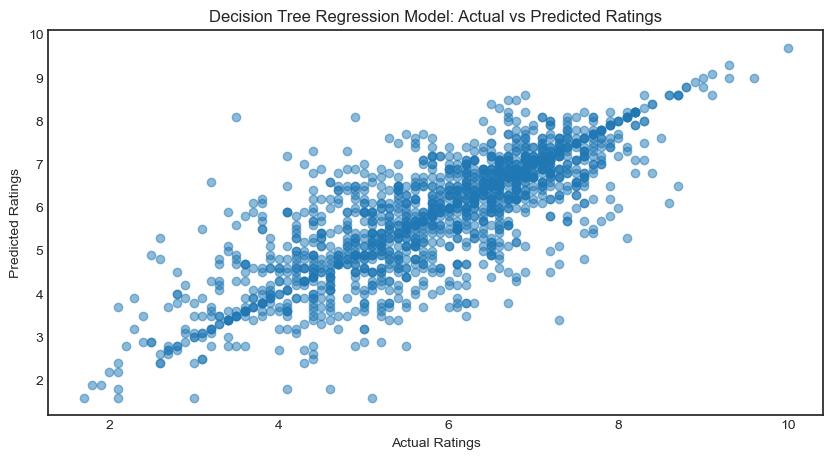

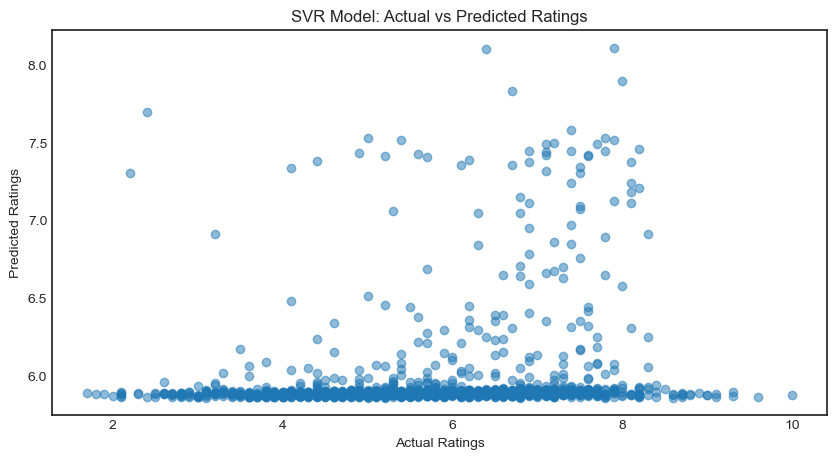

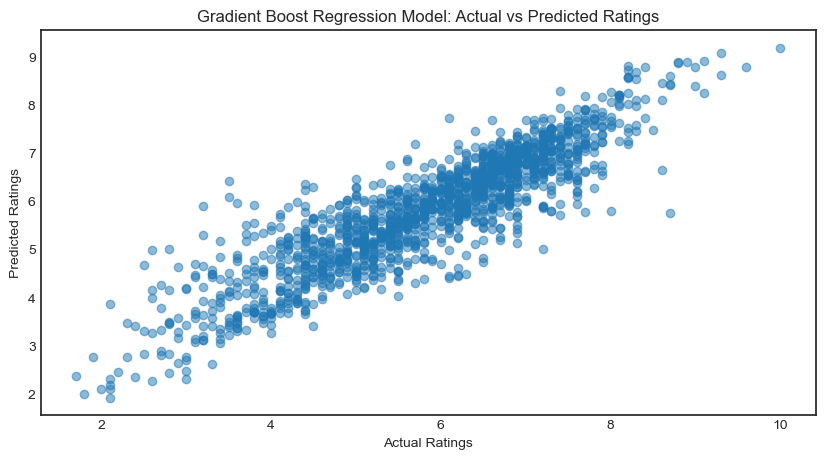

In [68]:
# Scatter plot for Decision Tree Regression model predictions
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.title('Decision Tree Regression Model: Actual vs Predicted Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.show()

# Scatter plot for SVR model predictions
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_svr, alpha=0.5)
plt.title('SVR Model: Actual vs Predicted Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.show()

# Scatter plot for Gradient Boost Regression model predictions
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.title('Gradient Boost Regression Model: Actual vs Predicted Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.show()

In [69]:
data = {'Year': [2018], 'Votes': [100] ,'Duration': [130], 'Genre_Average_Rating':[6.0],'Director_Average_Rating':[6.5],'Actor1_Average_Rating':[5.5],'Actor2_Average_Rating':[5.8],'Actor3_Average_Rating':[5.3]}
trail_data = pd.DataFrame(data)

In [70]:
# Predict rating using trial data
predict_rating = fitted_model_gb.predict(trail_data)
print('Predicted Rating for trial data: ',predict_rating[0])

Predicted Rating for trial data:  5.79617263081663


**Conclusion:**  
The Gradient Boost Regression model achieved an **R² score of 0.792**, indicating that it effectively explains **79.2%** of the variance in the target variable (**Rating**)—a higher percentage than the other two models. Furthermore, its **Mean Squared Error (MSE) of 0.389** and **Mean Absolute Error (MAE) of 0.454** are both lower than those of the **Decision Tree Regression** and **SVR Regression** models, reinforcing its superior predictive accuracy.  

These findings suggest that **Gradient Boost Regression** is the most effective model for predicting movie ratings. The insights derived from this analysis can help stakeholders in the film industry make informed decisions regarding **film production, marketing strategies, and audience engagement** to optimize movie success.